# Motor NBA (Next Best Action) - Retail Offline

Pipeline completo: EDA, validacion de datos, feature engineering, segmentacion (K-Means), modelo de propension (LightGBM), explicabilidad (SHAP) y monitoreo de drift (Evidently).

La combinacion de ambos modelos resuelve los dos frentes que necesita el asesor comercial en piso de venta:

- **Modelo de Clustering (K-Means)** responde el COMO atender al cliente: define el perfil de comportamiento, la psicologia de compra y el tono que el asesor debe usar.
- **Modelo Predictivo (LightGBM)** responde el QUE ofrecerle: define la categoria exacta de electrodomestico con mayor probabilidad de compra en esa visita.

---

In [1]:
import os
import sys

cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    project_root = os.path.abspath(os.path.join(cwd, '..'))
else:
    project_root = cwd
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import logging
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
from umap import UMAP

from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from python.data.preprocessing import clean_clientes, load_raw_data, save_processed
from python.features.build_features import build_customer_360
from python.models.predict import NBAPredictor
from python.models.train_propensity import (
    optimize_hyperparams,
    prepare_model_data,
    train_final_model,
)
from python.models.train_segmentation import (
    SEGMENT_FEATURES,
    find_optimal_k,
    train_segmentation,
)
from python.monitoring.drift_report import generate_drift_report

C:\Users\mdmgu\OneDrive\Documentos\mdm\pruebas_tecnicas\repositorio_haceb\motor-acciones-comerciales-retail-haceb\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('pipeline')
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Carga y exploracion de datos

Se cargan los tres datasets crudos desde `data/raw/` sin ninguna modificacion. El objetivo es entender la distribucion de las variables, el rango temporal y la relacion entre los tres archivos antes de aplicar cualquier transformacion.

| Dataset | Descripcion |
|---|---|
| `clientes.csv` | 200 registros con zona geografica, antiguedad, score de credito, celular y email |
| `transacciones.csv` | 450 compras con categoria de producto, monto, medio de pago y fecha |
| `interacciones_tienda.csv` | 300 visitas a tienda con motivo de visita y `compro_en_visita` (variable target) |

In [4]:
clientes, transacciones, interacciones = load_raw_data()

for nombre, df in [
    ('clientes', clientes),
    ('transacciones', transacciones),
    ('interacciones', interacciones),
]:
    logger.info(
        '%s: %d filas x %d cols | columnas: %s',
        nombre, *df.shape, list(df.columns),
    )

python.data.preprocessing - INFO - Datos cargados: clientes=200, transacciones=450, interacciones=300


pipeline - INFO - clientes: 200 filas x 6 cols | columnas: ['id_cliente', 'zona_geografica', 'antiguedad_meses', 'celular_contacto', 'email_contacto', 'score_credito_interno']


pipeline - INFO - transacciones: 450 filas x 8 cols | columnas: ['id_transaccion', 'id_cliente', 'fecha_compra', 'sku_producto', 'categoria_producto', 'monto_pago', 'id_tienda', 'medio_pago']


pipeline - INFO - interacciones: 300 filas x 6 cols | columnas: ['id_interaccion', 'id_cliente', 'id_tienda', 'fecha_visita', 'motivo_visita', 'compro_en_visita']


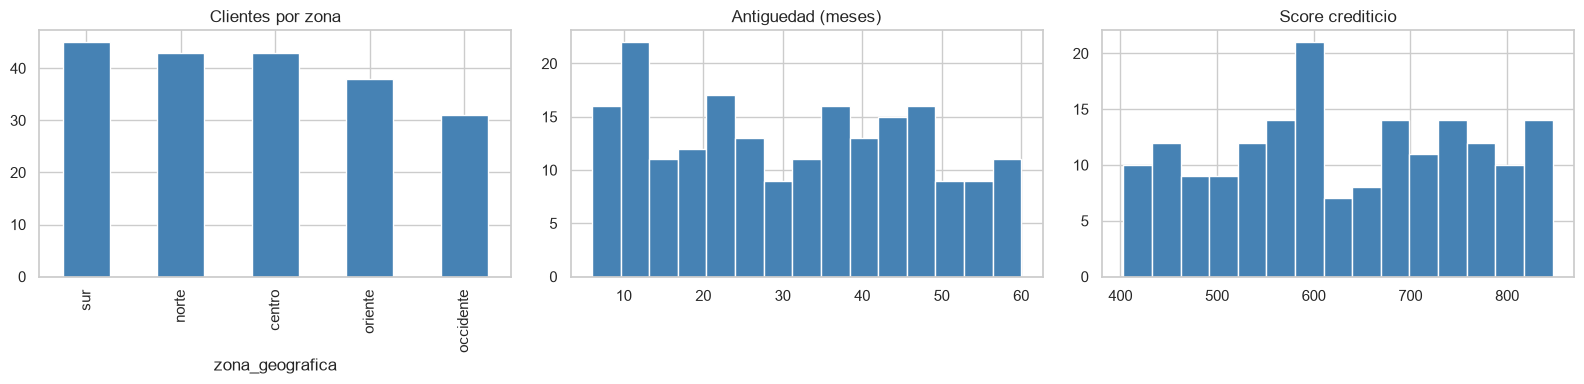

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

clientes['zona_geografica'].value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Clientes por zona')

axes[1].hist(clientes['antiguedad_meses'], bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Antiguedad (meses)')

clientes['score_credito_interno'].dropna().hist(bins=15, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Score crediticio')

plt.tight_layout()
plt.show()

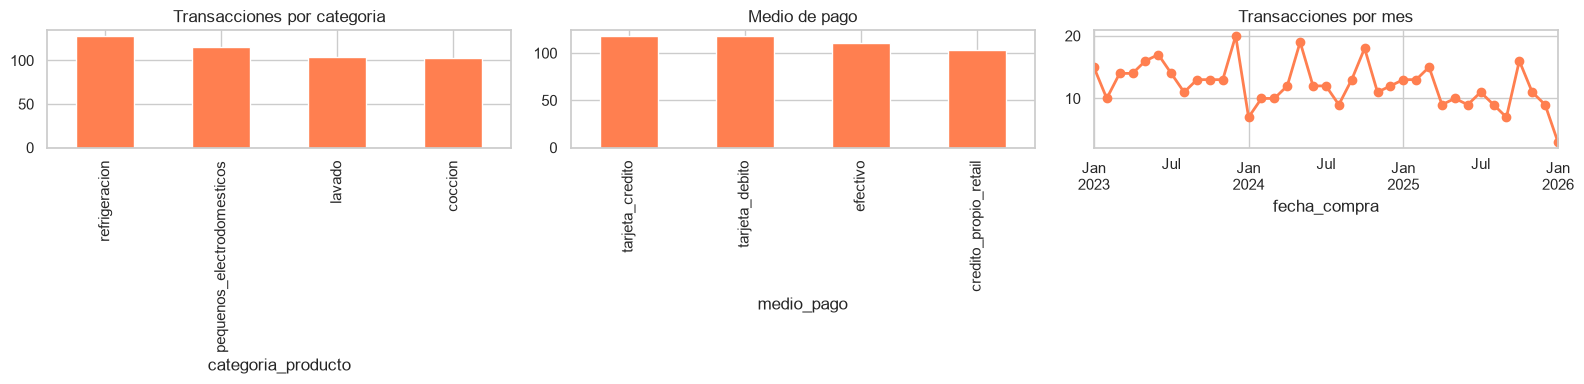

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

transacciones['categoria_producto'].value_counts().plot.bar(ax=axes[0], color='coral')
axes[0].set_title('Transacciones por categoria')

transacciones['medio_pago'].value_counts().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Medio de pago')

transacciones.set_index('fecha_compra').resample('M')['id_transaccion'].count().plot(
    ax=axes[2], color='coral', marker='o', linewidth=2)
axes[2].set_title('Transacciones por mes')

plt.tight_layout()
plt.show()

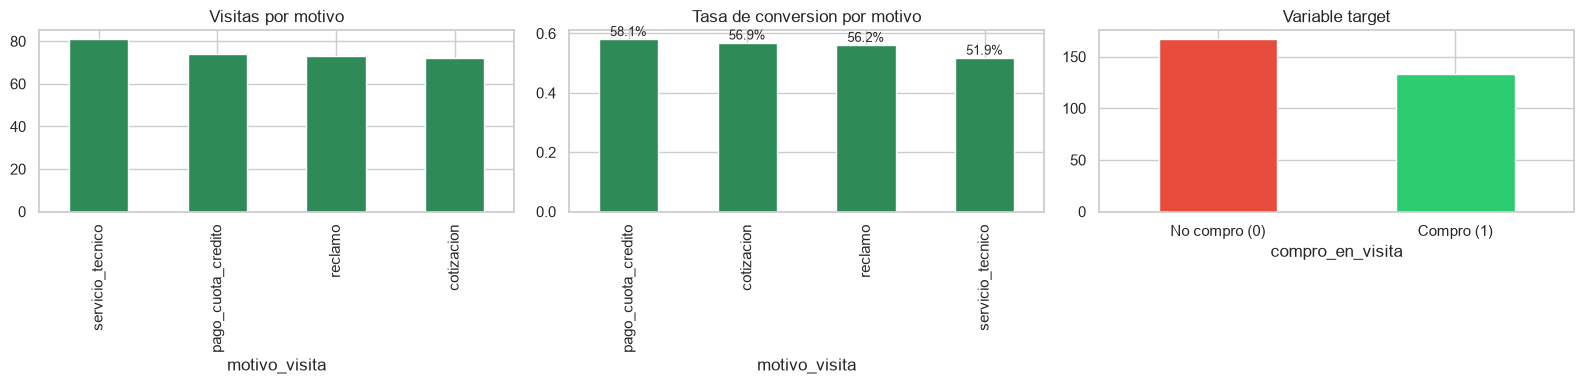

pipeline - INFO - Tasa de conversion global: 55.7%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

interacciones['motivo_visita'].value_counts().plot.bar(ax=axes[0], color='seagreen')
axes[0].set_title('Visitas por motivo')

conv_motivo = interacciones.groupby('motivo_visita')['compro_en_visita'].mean().sort_values(ascending=False)
conv_motivo.plot.bar(ax=axes[1], color='seagreen')
axes[1].set_title('Tasa de conversion por motivo')
for i, v in enumerate(conv_motivo):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

interacciones['compro_en_visita'].value_counts().plot.bar(ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_xticklabels(['No compro (0)', 'Compro (1)'], rotation=0)
axes[2].set_title('Variable target')

plt.tight_layout()
plt.show()

logger.info('Tasa de conversion global: %.1f%%', interacciones['compro_en_visita'].mean() * 100)

## 2. Validacion de calidad de datos

Se miden tres dimensiones de calidad antes de limpiar:

- **Completitud**: proporcion de registros sin valores nulos, vacios o literales como `"null"`.
- **Validez**: proporcion de registros que cumplen el formato esperado (regex de celular de 10 digitos y email con dominio).
- **Unicidad**: proporcion sin duplicados (relevante para `id_cliente`).

La cobertura entre datasets mide cuantos clientes aparecen en los tres archivos a la vez. Los clientes sin historial de transacciones o visitas recibiran ceros en las features correspondientes despues del merge con `left join`.

In [8]:
def completitud(series):
    total = len(series)
    problemas = series.isna().sum() + (series.astype(str).str.lower() == 'null').sum() + (series.astype(str).str.strip() == '').sum()
    return 1 - problemas / total

def validez_regex(series, pattern):
    return series.astype(str).apply(lambda x: bool(re.match(pattern, x))).mean()

quality = pd.DataFrame([
    {'variable': 'id_cliente', 'completitud': completitud(clientes['id_cliente']),
     'unicidad': 1 - clientes['id_cliente'].duplicated().mean()},
    {'variable': 'celular_contacto', 'completitud': completitud(clientes['celular_contacto']),
     'validez': validez_regex(clientes['celular_contacto'], r'^\d{10}$')},
    {'variable': 'email_contacto', 'completitud': completitud(clientes['email_contacto']),
     'validez': validez_regex(clientes['email_contacto'], r'^[\w.-]+@[\w.-]+\.\w+$')},
    {'variable': 'score_credito_interno', 'completitud': completitud(clientes['score_credito_interno'])},
]).set_index('variable')

quality.style.format('{:.1%}', na_rep='-').background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0)

,completitud,unicidad,validez
variable,,,
id_cliente,100.0%,100.0%,-
celular_contacto,74.5%,-,58.0%
email_contacto,73.5%,-,52.5%
score_credito_interno,88.5%,-,-


In [9]:
clientes_ids = set(clientes['id_cliente'])
tx_ids = set(transacciones['id_cliente'])
inter_ids = set(interacciones['id_cliente'])

logger.info('Clientes en catalogo: %d', len(clientes_ids))
logger.info('Clientes con transacciones: %d', len(tx_ids))
logger.info('Clientes con interacciones: %d', len(inter_ids))
logger.info('Clientes en los 3 datasets: %d', len(clientes_ids & tx_ids & inter_ids))

pipeline - INFO - Clientes en catalogo: 200


pipeline - INFO - Clientes con transacciones: 177


pipeline - INFO - Clientes con interacciones: 155


pipeline - INFO - Clientes en los 3 datasets: 138


## 3. Limpieza y Feature Engineering

`clean_clientes` resuelve los problemas detectados en la validacion:

1. **Celular y email invalidos**: en lugar de eliminar filas, se reemplazan por flags binarios `tiene_celular_valido` y `tiene_email_valido`. Que el dato no exista es informacion predictiva por si sola.
2. **Score de credito nulo**: se imputa con la mediana de clientes de la misma zona geografica. Si la zona no tiene datos suficientes, se usa la mediana global.

`build_customer_360` construye la tabla central del sistema: una fila por cliente con features RFM (recency, frequency, monetary) calculadas desde transacciones y features conductuales calculadas desde visitas. Internamente llama a `build_tx_features` y `build_inter_features`. Los clientes sin historial reciben cero en todas las features numericas.

In [10]:
clientes_clean = clean_clientes(clientes)
save_processed(clientes_clean, transacciones, interacciones)
c360 = build_customer_360(clientes_clean, transacciones, interacciones)
c360.head()

python.data.preprocessing - INFO - Clientes limpiados: 200 filas, 6 columnas


python.data.preprocessing - INFO - Datos procesados guardados en C:\Users\mdmgu\OneDrive\Documentos\mdm\pruebas_tecnicas\repositorio_haceb\motor-acciones-comerciales-retail-haceb\data\processed


python.features.build_features - INFO - Features de transacciones: 177 clientes, 10 features


python.features.build_features - INFO - Features de interacciones: 155 clientes, 8 features


python.features.build_features - INFO - Customer 360: 200 clientes, 22 features


,id_cliente,zona_geografica,antiguedad_meses,score_credito_interno,tiene_celular_valido,tiene_email_valido,recency_dias,frequency,monetary_total,monetary_avg,...,categoria_favorita,medio_pago_habitual,usa_credito_propio,total_visitas,tasa_conversion_hist,visitas_servicio_tecnico,visitas_cotizacion,visitas_reclamo,visitas_pago_cuota,dias_desde_ultima_visita
0,cli_001,norte,10,786.0,0,1,523.0,3.0,9590991.06,3196997.020,...,lavado,credito_propio_retail,1.0,2.0,0.5,2.0,0.0,0.0,0.0,13.0
1,cli_002,norte,51,523.0,0,1,82.0,1.0,2329885.80,2329885.800,...,lavado,tarjeta_debito,0.0,1.0,1.0,0.0,0.0,1.0,0.0,797.0
2,cli_003,oriente,46,553.0,1,1,117.0,5.0,14846198.89,2969239.778,...,pequenos_electrodomesticos,efectivo,1.0,2.0,0.5,0.0,0.0,0.0,2.0,247.0
3,cli_004,sur,9,473.0,1,1,0.0,0.0,0.00,0.000,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cli_005,sur,20,429.0,0,1,1058.0,1.0,2253790.05,2253790.050,...,coccion,tarjeta_credito,0.0,1.0,1.0,0.0,1.0,0.0,0.0,390.0


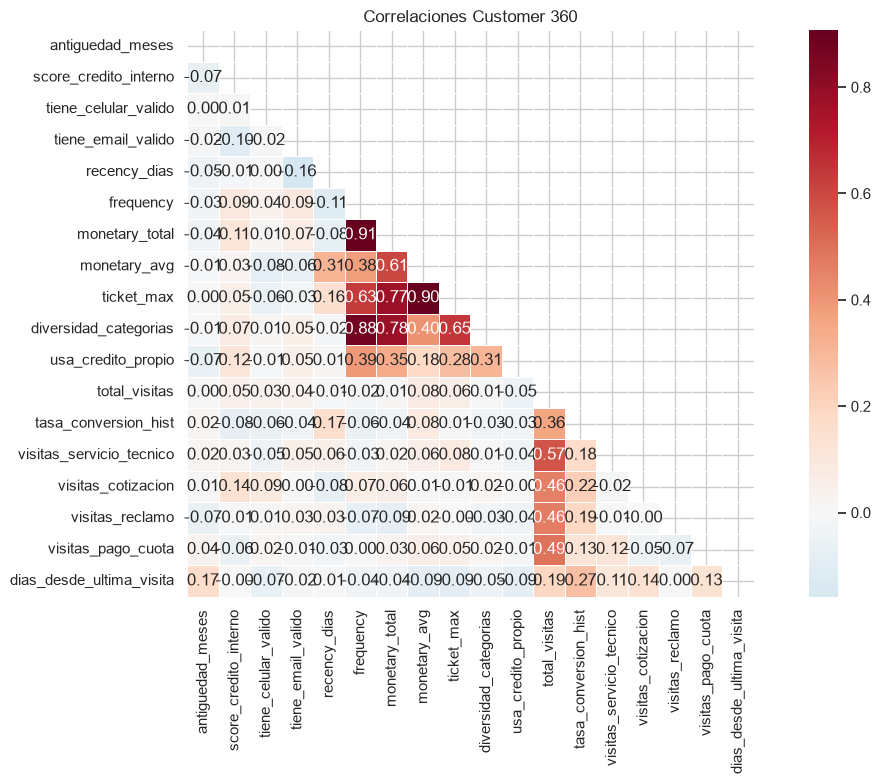

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
numeric = c360.select_dtypes(include=[np.number]).columns
corr = c360[numeric].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlaciones Customer 360')
plt.tight_layout()
plt.show()

## 4. Segmentacion de clientes

K-Means agrupa los clientes en segmentos sin supervision. Cada segmento representa un perfil de comportamiento distinto que le dice al asesor quien es el cliente antes de ver el score.

Antes de aplicar K-Means las features se escalan con `StandardScaler` (media 0, desviacion estandar 1). Esto es obligatorio porque K-Means usa distancia euclidiana: sin escalado, `monetary_total` (que puede ser millones) domina completamente sobre `frequency` (que puede ser 1 a 10).

El numero optimo de clusters `k` se elige con el **silhouette score**: mide que tan compactos y separados son los clusters (1 = perfecto, 0 = superposicion total). Se evaluan valores de k entre 2 y 7 y se selecciona el de mayor score.

La visualizacion **UMAP** proyecta las 10 features de segmentacion a 2 dimensiones para inspeccionar visualmente la estructura de los segmentos. UMAP preserva mejor la estructura local que PCA, lo que lo hace util para visualizar clusters.

python.models.train_segmentation - INFO - k=2 silhouette=0.1750 inertia=1581


python.models.train_segmentation - INFO - k=3 silhouette=0.1621 inertia=1376


python.models.train_segmentation - INFO - k=4 silhouette=0.1548 inertia=1261


python.models.train_segmentation - INFO - k=5 silhouette=0.1536 inertia=1158


python.models.train_segmentation - INFO - k=6 silhouette=0.1628 inertia=1087


python.models.train_segmentation - INFO - k=7 silhouette=0.1675 inertia=1029


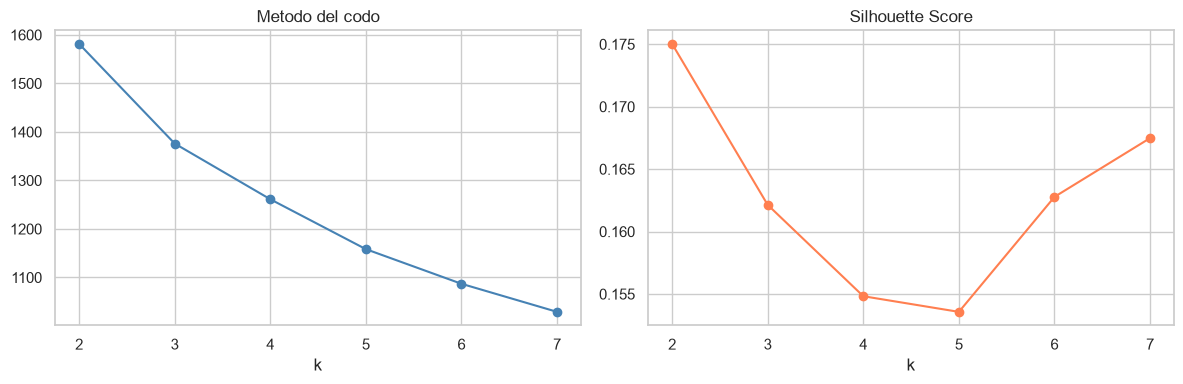

pipeline - INFO - Mejor k: 2


In [12]:
X_seg = c360[SEGMENT_FEATURES].fillna(0)
X_seg_scaled = StandardScaler().fit_transform(X_seg)
k_results = find_optimal_k(X_seg_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_results['k'], k_results['inertia'], 'o-', color='steelblue')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('k')

axes[1].plot(k_results['k'], k_results['silhouette'], 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')

plt.tight_layout()
plt.show()

best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
logger.info('Mejor k: %d', best_k)

In [13]:
c360_seg, km, scaler = train_segmentation(c360, n_clusters=best_k)
c360_seg.to_parquet(os.path.join('data', 'processed', 'customer_360.parquet'), index=False)

profile = c360_seg.groupby('segmento_nombre')[SEGMENT_FEATURES].mean().round(2)
profile

python.models.train_segmentation - INFO - Segmentacion entrenada: k=2, silhouette=0.1750


,recency_dias,frequency,monetary_total,monetary_avg,total_visitas,tasa_conversion_hist,usa_credito_propio,diversidad_categorias,score_credito_interno,antiguedad_meses
segmento_nombre,,,,,,,,,,
Cliente Financiado,309.48,3.48,8753529.73,2581441.16,1.6,0.41,0.56,2.53,645.49,30.58
VIP Comprador,403.18,1.07,2078014.32,1591118.53,1.4,0.46,0.20,1.01,613.68,31.40


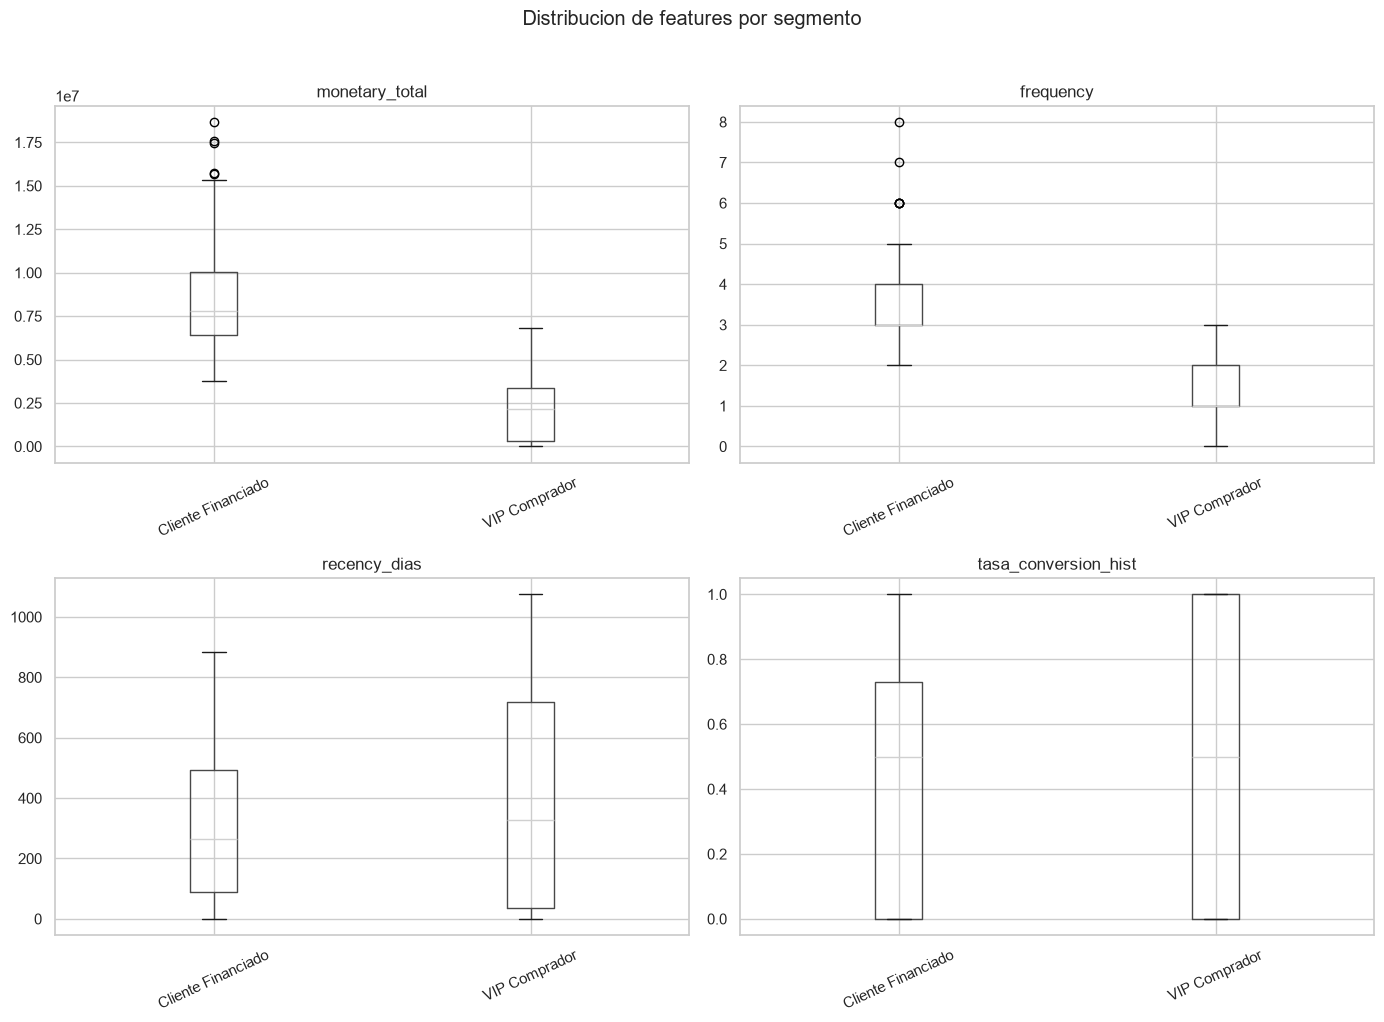

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ['monetary_total', 'frequency', 'recency_dias', 'tasa_conversion_hist']):
    c360_seg.boxplot(column=col, by='segmento_nombre', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks(rotation=25)
plt.suptitle('Distribucion de features por segmento', y=1.02)
plt.tight_layout()
plt.show()

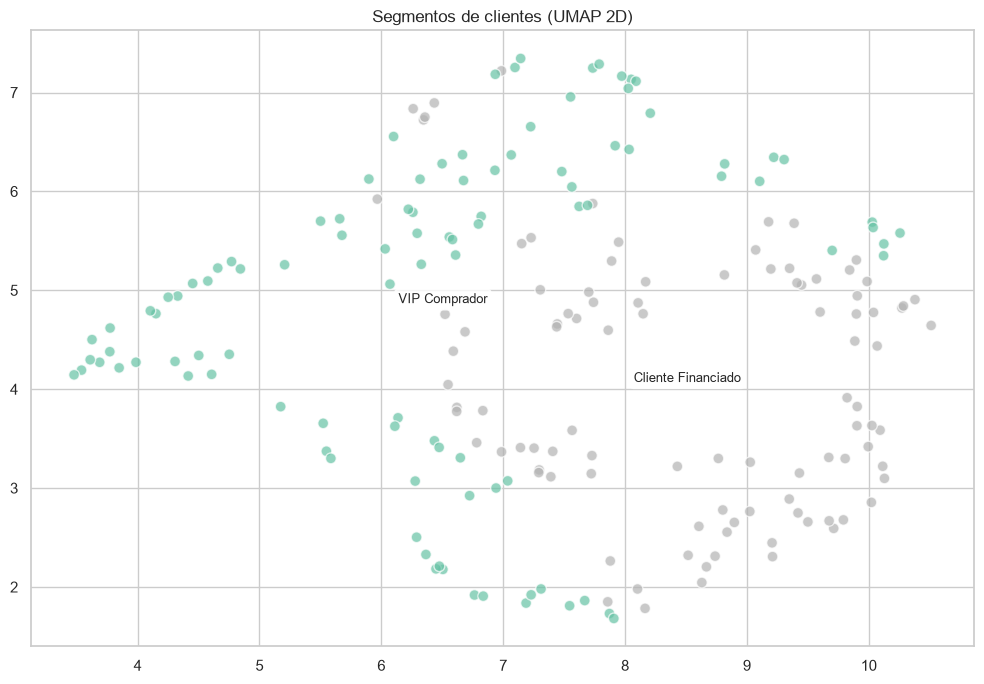

In [15]:
embedding = UMAP(
    n_components=2, random_state=42, n_neighbors=15
).fit_transform(X_seg_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=c360_seg['segmento_id'], cmap='Set2',
    s=60, alpha=0.7, edgecolors='white',
)
for seg_id in c360_seg['segmento_id'].unique():
    mask = c360_seg['segmento_id'] == seg_id
    name = c360_seg.loc[mask, 'segmento_nombre'].iloc[0]
    cx, cy = embedding[mask].mean(axis=0)
    ax.annotate(
        name, (cx, cy), fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
    )
ax.set_title('Segmentos de clientes (UMAP 2D)')
plt.tight_layout()
plt.show()

## 5. Seleccion de modelo

Se comparan cuatro modelos con validacion cruzada estratificada de 5 folds sin ajuste de hiperparametros. El objetivo es confirmar que familia de modelo es la mas adecuada antes de invertir tiempo en optimizacion.

**Por que validacion cruzada estratificada**: garantiza que cada fold mantiene la misma proporcion de positivos y negativos que el dataset original. Con datasets pequenos y clases desbalanceadas, esto evita que un fold tenga muy pocos positivos y produzca estimaciones de AUC poco confiables.

**Por que AUC-ROC**: mide la capacidad discriminativa del modelo para todos los umbrales de decision posibles. Un AUC de 0.5 equivale a prediccion aleatoria; 1.0 es perfecta. Es la metrica correcta cuando el costo de falsos positivos y falsos negativos no esta definido de antemano.

Logistic Regression requiere escalado previo. Los modelos basados en arboles (Random Forest, Gradient Boosting, LightGBM) no lo requieren porque las divisiones de los arboles son invariantes a la escala.

python.models.train_propensity - INFO - Datos preparados: 300 obs, 20 features, target=55.7%


pipeline - INFO - Logistic Regression: AUC=0.8673 (+/- 0.0370)


pipeline - INFO - Random Forest: AUC=0.7632 (+/- 0.0450)


pipeline - INFO - Gradient Boosting: AUC=0.8209 (+/- 0.0505)


pipeline - INFO - LightGBM: AUC=0.8195 (+/- 0.0485)


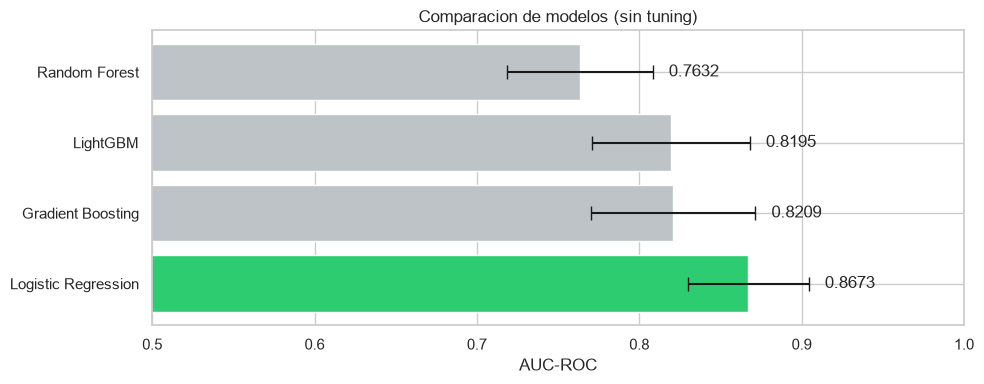

In [16]:
X, y, enc = prepare_model_data(c360_seg, interacciones)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler_lr = StandardScaler()
X_scaled = scaler_lr.fit_transform(X)

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

resultados = []
for nombre, modelo in modelos.items():
    X_in = X_scaled if 'Logistic' in nombre else X
    scores = cross_val_score(modelo, X_in, y, cv=cv, scoring='roc_auc')
    resultados.append({'modelo': nombre, 'auc_mean': scores.mean(), 'auc_std': scores.std()})
    logger.info('%s: AUC=%.4f (+/- %.4f)', nombre, scores.mean(), scores.std())

df_res = pd.DataFrame(resultados).sort_values('auc_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if i == 0 else '#bdc3c7' for i in range(len(df_res))]
ax.barh(df_res['modelo'], df_res['auc_mean'], xerr=df_res['auc_std'], color=colors, capsize=5)
ax.set_xlabel('AUC-ROC')
ax.set_title('Comparacion de modelos (sin tuning)')
ax.set_xlim(0.5, 1.0)
for i, (m, s) in enumerate(zip(df_res['auc_mean'], df_res['auc_std'])):
    ax.text(m + s + 0.01, i, f'{m:.4f}', va='center')
plt.tight_layout()
plt.show()

## 6. Modelo final: LightGBM + Optuna + MLflow

Se optimizan los hiperparametros de LightGBM con Optuna usando **busqueda bayesiana (TPE)**. A diferencia de grid search (prueba todas las combinaciones) o random search (prueba al azar), TPE construye un modelo probabilistico que aprende que regiones del espacio producen mejor AUC y dirige los siguientes trials hacia esas regiones. Con 50 trials se obtiene una aproximacion eficiente al optimo global.

Los hiperparametros que se optimizan:

| Parametro | Que controla |
|---|---|
| `n_estimators` | Numero de arboles en el ensemble |
| `learning_rate` | Cuanto aporta cada arbol; valores bajos necesitan mas arboles |
| `max_depth` | Profundidad maxima de cada arbol; limita la complejidad |
| `min_child_samples` | Minimo de muestras por hoja; regularizacion para datasets pequenos |
| `subsample` / `colsample_bytree` | Muestreo aleatorio de filas y columnas por arbol; reduce overfitting |
| `reg_alpha` / `reg_lambda` | Regularizacion L1 y L2 sobre los pesos de las hojas |

El modelo final se registra en **MLflow** con todos los parametros y metricas de validacion cruzada. MLflow guarda todo en `mlruns/` y permite comparar runs en `http://localhost:5000`.

python.models.train_propensity - INFO - Optuna best AUC: 0.8889 params: {'n_estimators': 247, 'learning_rate': 0.02187282735231585, 'max_depth': 3, 'min_child_samples': 37, 'subsample': 0.8445121014298893, 'colsample_bytree': 0.8021104803958379, 'reg_alpha': 6.572554138703497, 'reg_lambda': 0.13706889688003407}


pipeline - INFO - Mejor AUC Optuna: 0.8889


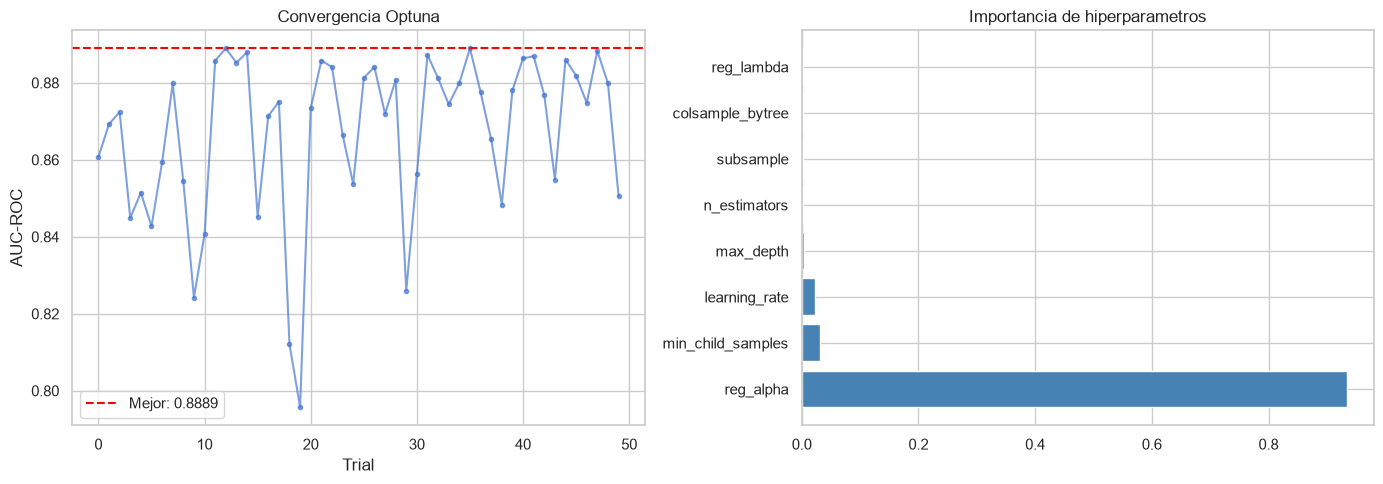

In [17]:
study = optimize_hyperparams(X, y, n_trials=50)
logger.info('Mejor AUC Optuna: %.4f', study.best_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', markersize=3, alpha=0.7)
axes[0].axhline(
    y=study.best_value, color='red', linestyle='--',
    label=f'Mejor: {study.best_value:.4f}',
)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Convergencia Optuna')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_title('Importancia de hiperparametros')
plt.tight_layout()
plt.show()

In [18]:
model, cv_scores = train_final_model(X, y, study.best_params)
logger.info('Modelo final AUC: %.4f (+/- %.4f)', cv_scores.mean(), cv_scores.std())

2026/07/01 13:29:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/01 13:29:33 INFO mlflow.store.db.utils: Updating database tables


2026/07/01 13:29:49 INFO mlflow.tracking.fluent: Experiment with name 'propension_compra_visita' does not exist. Creating a new experiment.


2026/07/01 13:29:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


python.models.train_propensity - INFO - Modelo final: AUC CV=0.8889 (+/- 0.0250)


pipeline - INFO - Modelo final AUC: 0.8889 (+/- 0.0250)


## 7. Evaluacion del modelo

Se evalua el modelo con tres perspectivas complementarias y una metrica de negocio:

- **Curva ROC**: muestra el trade-off entre tasa de verdaderos positivos (sensibilidad) y tasa de falsos positivos para todos los umbrales posibles. El AUC resume en un numero la capacidad discriminativa.
- **Curva Precision-Recall**: relevante cuando la clase positiva es minoritaria. Precision es de los que predije como compra, cuantos realmente compraron. Recall es de los que compraron, cuantos detecte.
- **Matriz de confusion**: conteos de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos con umbral de decision 0.5.
- **Lift por decil**: la metrica de negocio. Ordena los clientes por score descendente, los divide en 10 grupos y compara la tasa de compra real de cada grupo contra el baseline (tasa global). Un lift de 1.8x en el decil top significa que los clientes con mayor score compran 1.8 veces mas que el promedio: con este modelo se puede concentrar el esfuerzo del asesor en el 10% de clientes con mayor probabilidad de compra y obtener 1.8 veces mas conversiones que sin modelo.

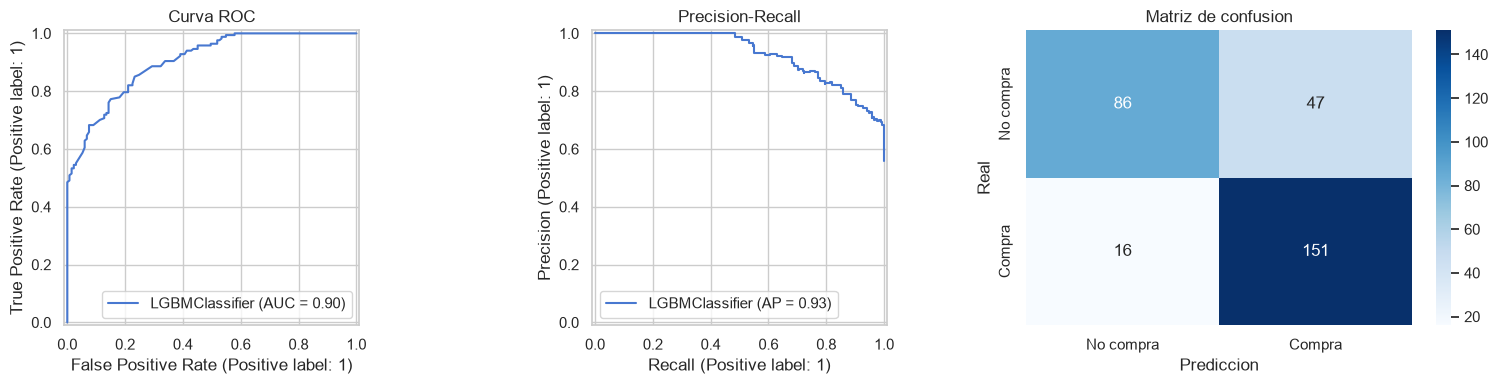

pipeline - INFO - 
              precision    recall  f1-score   support

   No compra       0.84      0.65      0.73       133
      Compra       0.76      0.90      0.83       167

    accuracy                           0.79       300
   macro avg       0.80      0.78      0.78       300
weighted avg       0.80      0.79      0.79       300



In [19]:
y_proba = model.predict_proba(X)[:, 1]
y_pred = model.predict(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

RocCurveDisplay.from_estimator(model, X, y, ax=axes[0])
axes[0].set_title('Curva ROC')

PrecisionRecallDisplay.from_estimator(model, X, y, ax=axes[1])
axes[1].set_title('Precision-Recall')

cm = confusion_matrix(y, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
    xticklabels=['No compra', 'Compra'],
    yticklabels=['No compra', 'Compra'],
)
axes[2].set_title('Matriz de confusion')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

logger.info('\n%s', classification_report(y, y_pred, target_names=['No compra', 'Compra']))

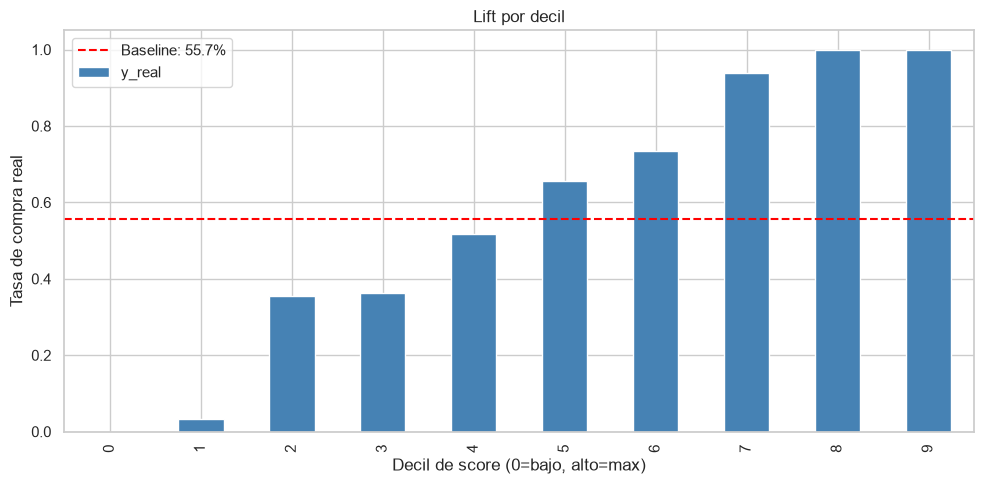

pipeline - INFO - Lift decil top: 1.80x vs baseline


In [20]:
lift_df = pd.DataFrame({'y_real': y, 'score': y_proba})
lift_df['decil'] = pd.qcut(lift_df['score'], 10, labels=False, duplicates='drop')
lift_by_decil = lift_df.groupby('decil')['y_real'].mean()
baseline = y.mean()

fig, ax = plt.subplots(figsize=(10, 5))
lift_by_decil.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline: {baseline:.1%}')
ax.set_xlabel('Decil de score (0=bajo, alto=max)')
ax.set_ylabel('Tasa de compra real')
ax.set_title('Lift por decil')
ax.legend()
plt.tight_layout()
plt.show()

logger.info('Lift decil top: %.2fx vs baseline', lift_by_decil.iloc[-1] / baseline)

## 8. Explicabilidad SHAP

SHAP (SHapley Additive exPlanations) cuantifica la contribucion de cada feature a cada prediccion individual. Se basa en la teoria de juegos cooperativos: el valor SHAP de una feature es su aporte marginal promedio a la prediccion considerando todas las combinaciones posibles de features.

`TreeExplainer` es la implementacion eficiente de SHAP para arboles de decision. Calcula valores exactos (no aproximaciones) aprovechando la estructura del arbol.

- **Summary plot (barras)**: importancia global. Las features con mayor valor SHAP absoluto promedio son las mas influyentes en el modelo.
- **Summary plot (beeswarm)**: distribucion de los valores SHAP por feature. El color indica el valor de la feature (rojo = valor alto, azul = valor bajo) y la posicion horizontal indica el impacto en el score (positivo = empuja hacia compra, negativo = frena).
- **Force plot**: explicacion de una prediccion individual. Muestra que features empujan el score hacia arriba (rojo) y cuales lo bajan (azul) respecto al valor base del modelo. Esto es lo que permite al sistema justificarle al asesor por que el modelo dice que ese cliente va a comprar.

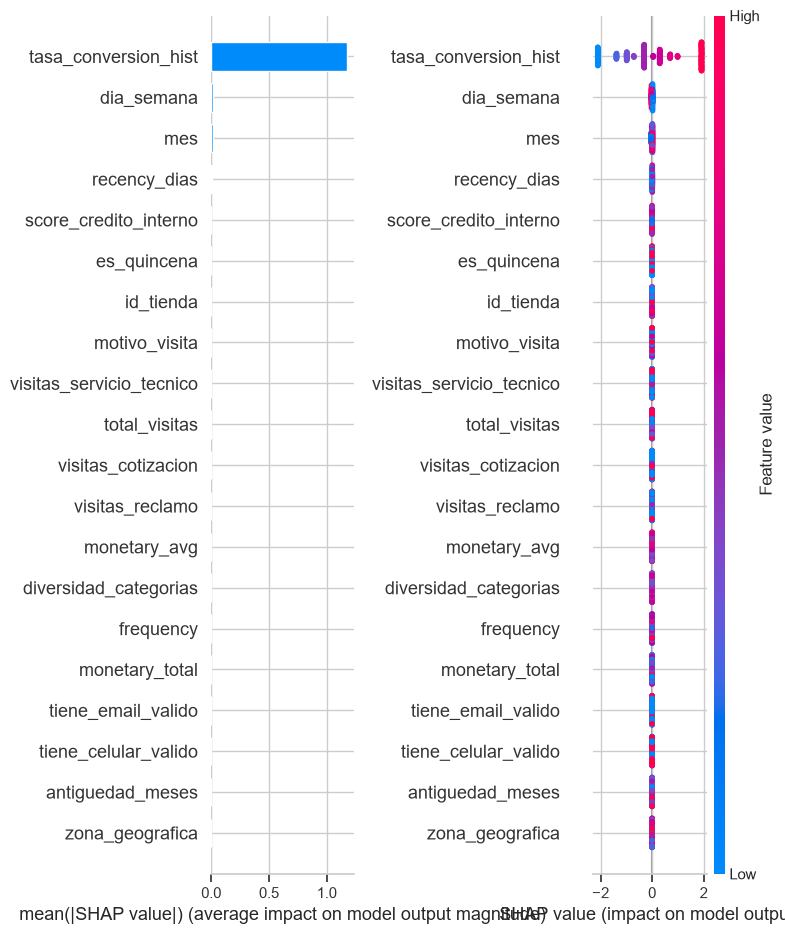

In [21]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_vals, X, plot_type='bar', show=False)
plt.sca(axes[1])
shap.summary_plot(shap_vals, X, show=False)
plt.tight_layout()
plt.show()

pipeline - INFO - Ejemplo: obs 15, score=0.908


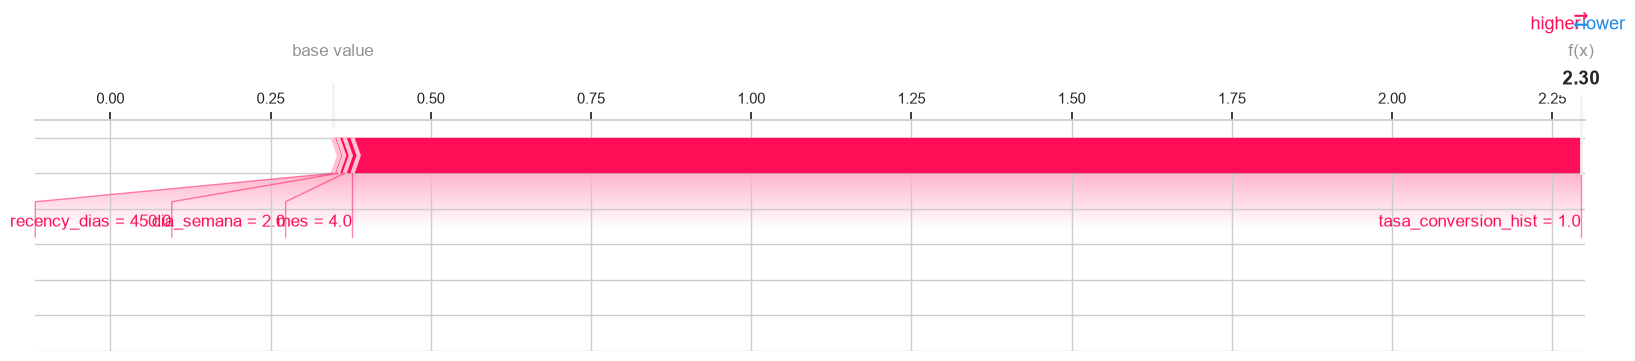

<Figure size 1200x500 with 0 Axes>

In [22]:
idx = y_proba.argmax()
logger.info('Ejemplo: obs %d, score=%.3f', idx, y_proba[idx])

ev = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
shap.force_plot(ev, shap_vals[idx], X.iloc[idx], matplotlib=True)
plt.tight_layout()
plt.show()

## 9. Monitoreo de drift

El **drift** ocurre cuando la distribucion de los datos en produccion cambia respecto a los datos de entrenamiento. Si el drift es significativo, el modelo fue entrenado con una realidad que ya no existe y sus predicciones se vuelven menos confiables.

**Evidently** compara estadisticamente la distribucion de cada feature entre un dataset de referencia y un dataset actual. Aplica la prueba de Kolmogorov-Smirnov para features numericas y chi-cuadrado para features categoricas. El resultado es un reporte HTML navegable con graficos de distribucion superpuesta y un semaforo de drift por feature.

Para esta demo se usa la primera mitad de `X` como referencia y la segunda mitad como datos actuales. En produccion, la referencia seria el conjunto de entrenamiento y el actual seria el batch de visitas del ultimo mes. Si el reporte detecta drift en features criticas como `monetary_total` o `tasa_conversion_hist`, es la senal para reentrenar el modelo.

In [23]:
mid = len(X) // 2
ref = X.iloc[:mid].loc[:, :]
cur = X.iloc[mid:].loc[:, :]
ref['target'] = y.iloc[:mid].values
cur['target'] = y.iloc[mid:].values

report_path = generate_drift_report(ref, cur)
logger.info('Drift report: %s', report_path)

python.monitoring.drift_report - INFO - Reporte de drift guardado en C:\Users\mdmgu\OneDrive\Documentos\mdm\pruebas_tecnicas\repositorio_haceb\motor-acciones-comerciales-retail-haceb\reports\drift_report.html


pipeline - INFO - Drift report: C:\Users\mdmgu\OneDrive\Documentos\mdm\pruebas_tecnicas\repositorio_haceb\motor-acciones-comerciales-retail-haceb\reports\drift_report.html


## 10. Test del predictor end-to-end

Se valida que el pipeline completo de inferencia funciona correctamente. `NBAPredictor` carga los cuatro artefactos desde `models/` y el Customer 360 desde `data/processed/`, y produce una recomendacion completa dado un `id_cliente` y un `motivo_visita`.

Este test simula exactamente lo que hace la API cuando recibe un request `POST /predict`: los mismos artefactos, el mismo encoder, la misma logica de segmentacion, el mismo modelo de propension. Si este test pasa, la API funcionara correctamente.

La respuesta incluye: segmento del cliente, score de propension (0-1), nivel de urgencia (ALTO/MEDIO/BAJO), la categoria de producto recomendada y el texto de accion para el asesor.

In [24]:
predictor = NBAPredictor()

for cid, motivo in [
    ('cli_043', 'pago_cuota_credito'),
    ('cli_001', 'cotizacion'),
    ('cli_100', 'servicio_tecnico'),
]:
    result = predictor.predict(cid, motivo)
    logger.info(
        '%s (%s) -> %s | score=%.3f | accion: %s',
        cid, motivo, result['segmento'],
        result['score_compra_hoy'], result['accion_recomendada'],
    )

python.models.predict - INFO - NBAPredictor inicializado


pipeline - INFO - cli_043 (pago_cuota_credito) -> Cliente Financiado | score=0.150 | accion: Mostrar pequenos_electrodomesticos con financiacion a 24 cuotas - prioridad baja, no presionar


pipeline - INFO - cli_001 (cotizacion) -> Cliente Financiado | score=0.516 | accion: Mostrar coccion con financiacion a 24 cuotas


pipeline - INFO - cli_100 (servicio_tecnico) -> Cliente Financiado | score=0.150 | accion: Mostrar refrigeracion con financiacion a 24 cuotas - prioridad baja, no presionar


---

Pipeline completo ejecutado. Los artefactos estan en `models/` y los datos procesados en `data/processed/`. Para levantar los servicios:

```bash
mlflow ui                                       # http://localhost:5000
uvicorn python.api.main:app --reload            # http://localhost:8000
streamlit run python/front/app.py               # http://localhost:8501
```